# ML Benchmark — Fe@IPSHC/β-CD CIP Adsorption Capacity Prediction

This notebook trains and compares **six regression models** to predict the equilibrium adsorption capacity (`qe`, mg g⁻¹) of CIP onto Fe@IPSHC/β-CD using five features: **Time, Temperature, pH, C₀, Dosage**.

**Models compared:**

| Model | Family | Why it's included |
|---|---|---|
| MLR | Linear | Baseline — proves non-linearity is needed |
| SVR | Kernel method | Strong on small datasets |
| KNN | Instance-based | Captures local patterns |
| MLP | Neural network | Comparison with deep learning |
| RF  | Bagging ensemble | Robust, interpretable |
| GBR | Boosting ensemble | sklearn equivalent of XGBoost/LightGBM |

**Pipeline:** 80/20 stratified train/test split → 5-fold CV grid search on training set → evaluate on hold-out test set → plot results.

---


## 1. Imports and configuration

In [1]:
# Suppress warnings (clean output)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

# Make plots render inline
%matplotlib inline

# ─── Configuration ───
DATA_FILE   = "FeIPSHC_bCD_ML_Dataset.csv"   # ← put this CSV in the same folder as the notebook
TEST_SIZE   = 0.20
RANDOM_SEED = 42

FEATURES = ["Time(min)", "Temperature(°C)", "pH", "C0(mg/L)", "Dosage(g/L)"]
TARGET   = "qe(mg/g)"

np.random.seed(RANDOM_SEED)

print("✓ Imports done.")

✓ Imports done.


## 2. Load data and split

Stratified split by `Source` so each experiment type (Dosage, pH, Kinetics, LowConc, Thermo) appears in both train and test.


In [2]:
df = pd.read_csv(DATA_FILE)
print(f"Loaded: {df.shape[0]} samples, columns = {list(df.columns)}")
df.head()

Loaded: 64 samples, columns = ['Time(min)', 'Temperature(°C)', 'pH', 'C0(mg/L)', 'Dosage(g/L)', 'qe(mg/g)', 'Source']


,Time(min),Temperature(°C),pH,C0(mg/L),Dosage(g/L),qe(mg/g),Source
0,1440,25,6,5.0,0.1,41.48,Dosage
1,1440,25,6,5.0,0.2,22.09,Dosage
2,1440,25,6,5.0,0.4,11.55,Dosage
3,1440,25,6,5.0,0.6,7.96,Dosage
4,1440,25,6,5.0,0.8,5.95,Dosage


In [3]:
X = df[FEATURES].values
y = df[TARGET].values
src = df["Source"].values if "Source" in df.columns else None

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=src
)
print(f"Train n = {len(y_tr)}   Test n = {len(y_te)}")
if src is not None:
    src_tr, src_te = train_test_split(
        src, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=src
    )
    print("Train source distribution:", pd.Series(src_tr).value_counts().to_dict())
    print("Test  source distribution:", pd.Series(src_te).value_counts().to_dict())

Train n = 51   Test n = 13
Train source distribution: {'Thermo': 24, 'Kinetics': 12, 'pH': 6, 'Dosage': 5, 'LowConc': 4}
Test  source distribution: {'Thermo': 6, 'Kinetics': 3, 'pH': 2, 'LowConc': 1, 'Dosage': 1}


## 3. Define models and hyperparameter grids

Each model is wrapped in a `Pipeline` (scaler + estimator where appropriate).

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

specs = {
    "MLR": (
        Pipeline([("scaler", StandardScaler()),
                  ("model", LinearRegression())]),
        {}   # no hyperparameters to tune
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()),
                  ("model", SVR(kernel="rbf"))]),
        {
            "model__C":       [10, 50, 100],
            "model__gamma":   [0.05, 0.1, 0.3],
            "model__epsilon": [0.01, 0.1],
        }
    ),
    "RF": (
        Pipeline([("model", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=1))]),
        {
            "model__n_estimators":     [300],
            "model__max_depth":        [None, 8, 12],
            "model__min_samples_leaf": [1, 2],
        }
    ),
    "GBR": (
        Pipeline([("model", GradientBoostingRegressor(random_state=RANDOM_SEED))]),
        {
            "model__n_estimators":  [300],
            "model__learning_rate": [0.05, 0.08],
            "model__max_depth":     [3, 4],
            "model__subsample":     [0.85],
        }
    ),
    "KNN": (
        Pipeline([("scaler", StandardScaler()),
                  ("model", KNeighborsRegressor())]),
        {
            "model__n_neighbors": [2, 3, 4, 5],
            "model__weights":     ["uniform", "distance"],
            "model__p":           [1, 2],
        }
    ),
    "MLP": (
        Pipeline([("scaler", StandardScaler()),
                  ("model", MLPRegressor(max_iter=5000, random_state=RANDOM_SEED,
                                          early_stopping=True, validation_fraction=0.15))]),
        {
            "model__hidden_layer_sizes": [(64,), (32, 16), (64, 32)],
            "model__alpha":              [1e-3, 1e-2],
            "model__learning_rate_init": [0.005, 0.01],
        }
    ),
}

print(f"✓ Defined {len(specs)} models.")

✓ Defined 6 models.


## 4. Train all models with grid-search CV

This cell takes ~1–2 minutes on a typical laptop. The progress prints which model is currently being tuned.

In [5]:
results, predictions, best_params = {}, {}, {}

for name, (pipe, grid) in specs.items():
    print(f"[{name}] tuning ...")
    if grid:
        gs = GridSearchCV(pipe, grid, cv=cv, scoring="r2", n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr)
        best        = gs.best_estimator_
        best_params[name] = gs.best_params_
        cv_r2       = gs.best_score_
    else:
        best = pipe.fit(X_tr, y_tr)
        best_params[name] = "default"
        cv_r2 = cross_val_score(best, X_tr, y_tr, cv=cv, scoring="r2").mean()

    yhat_tr = best.predict(X_tr)
    yhat_te = best.predict(X_te)

    results[name] = {
        "R2_train":   r2_score(y_tr, yhat_tr),
        "R2_cv":      cv_r2,
        "R2_test":    r2_score(y_te, yhat_te),
        "RMSE_train": np.sqrt(mean_squared_error(y_tr, yhat_tr)),
        "RMSE_test":  np.sqrt(mean_squared_error(y_te, yhat_te)),
        "MAE_train":  float(np.mean(np.abs(y_tr - yhat_tr))),
        "MAE_test":   float(np.mean(np.abs(y_te - yhat_te))),
    }
    predictions[name] = {"yhat_tr": yhat_tr, "yhat_te": yhat_te}

    print(f"   best params : {best_params[name]}")
    print(f"   R²: train={results[name]['R2_train']:.4f}  CV={cv_r2:.4f}  test={results[name]['R2_test']:.4f}")
    print(f"   RMSE: train={results[name]['RMSE_train']:.3f}  test={results[name]['RMSE_test']:.3f}\n")

print("✓ All models trained.")

[MLR] tuning ...
   best params : default
   R²: train=0.8344  CV=0.6748  test=0.9280
   RMSE: train=11.027  test=9.134

[SVR] tuning ...
   best params : {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 0.3}
   R²: train=0.9875  CV=0.8888  test=0.9066
   RMSE: train=3.033  test=10.399

[RF] tuning ...
   best params : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
   R²: train=0.9918  CV=0.9351  test=0.9533
   RMSE: train=2.452  test=7.353

[GBR] tuning ...
   best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.85}
   R²: train=0.9984  CV=0.9326  test=0.9831
   RMSE: train=1.078  test=4.422

[KNN] tuning ...
   best params : {'model__n_neighbors': 2, 'model__p': 2, 'model__weights': 'distance'}
   R²: train=0.9986  CV=0.8227  test=0.9699
   RMSE: train=1.019  test=5.902

[MLP] tuning ...
   best params : {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,), 'model__le

## 5. Summary table

In [6]:
res_df = pd.DataFrame(results).T[
    ["R2_train", "R2_cv", "R2_test", "RMSE_train", "RMSE_test", "MAE_train", "MAE_test"]
]
res_df = res_df.round(4)
res_df.to_csv("ml_metrics.csv")
res_df

,R2_train,R2_cv,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test
MLR,0.8344,0.6748,0.9280,11.0274,9.1341,8.5276,6.4625
SVR,0.9875,0.8888,0.9066,3.0329,10.3987,1.7410,6.3450
RF,0.9918,0.9351,0.9533,2.4516,7.3529,1.5229,4.5285
GBR,0.9984,0.9326,0.9831,1.0783,4.4224,0.5492,3.1356
KNN,0.9986,0.8227,0.9699,1.0187,5.9016,0.3104,3.4350
MLP,0.7466,0.6158,0.8352,13.6423,13.8150,9.9894,10.8271


## 6. Plot — predicted vs experimental qₑ for all six models

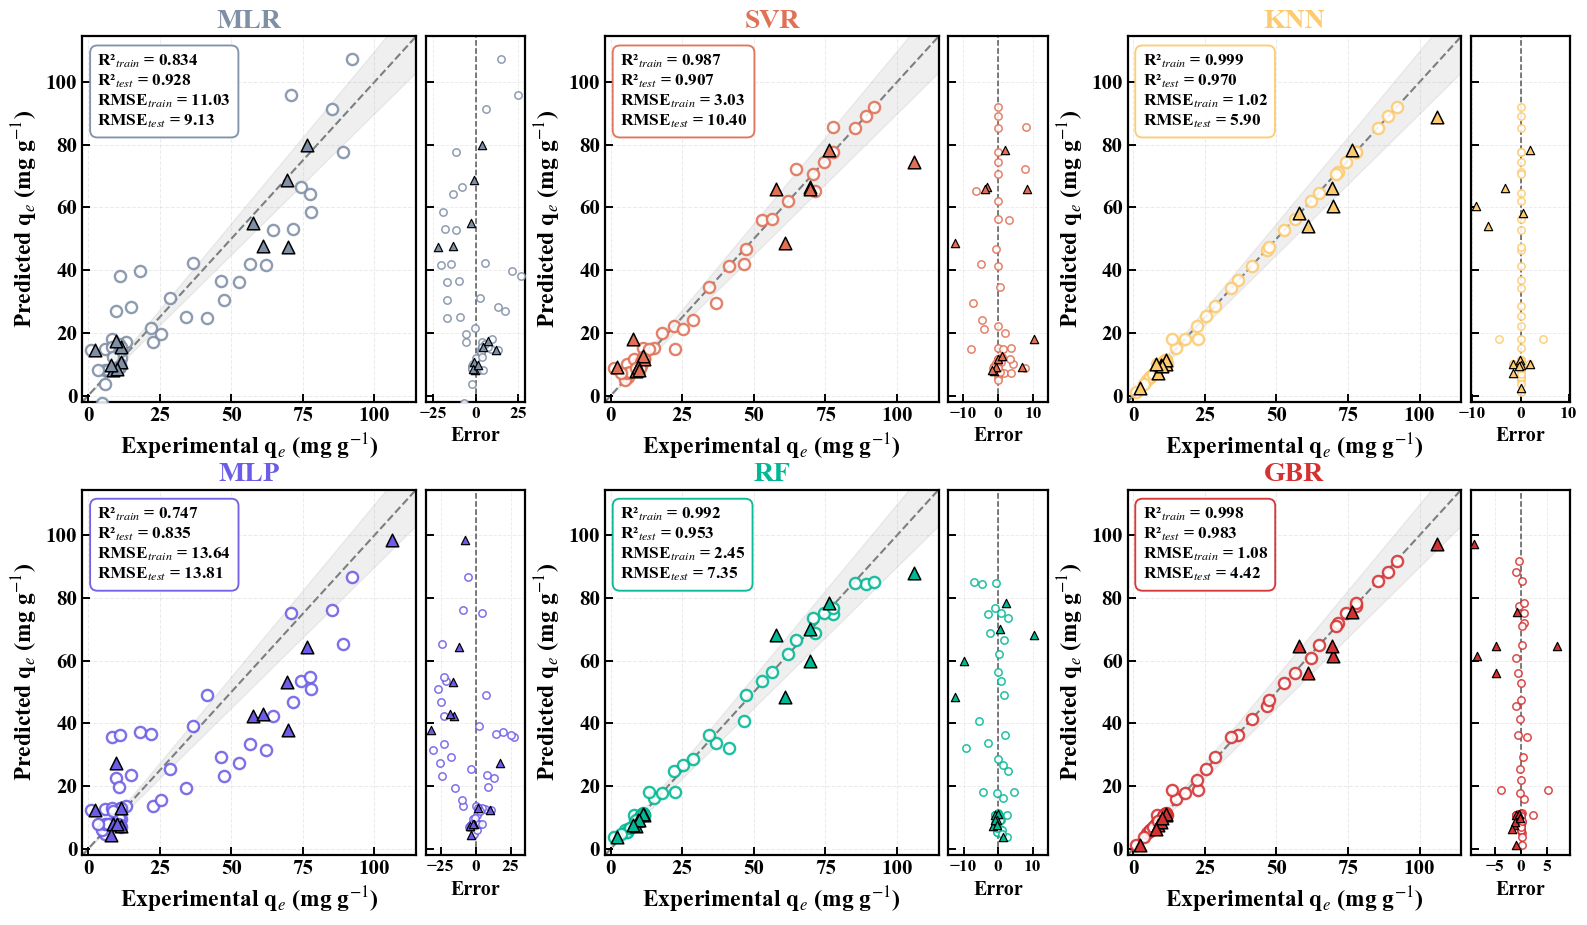

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # 字体整体放大
    "font.size": 16,

    # 坐标轴
    "axes.linewidth": 1.6,
    "axes.labelsize": 17,
    "axes.labelweight": "bold",
    "axes.titlesize": 20,
    "axes.titleweight": "bold",

    # 刻度
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.4,
    "ytick.major.width": 1.4,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # 图例
    "legend.frameon": False,
})

palette = {
    "MLR": "#7F8FA6",
    "SVR": "#E17055",
    "KNN": "#FDCB6E",
    "MLP": "#6C5CE7",
    "RF":  "#00B894",
    "GBR": "#D63031"
}

order = ["MLR", "SVR", "KNN", "MLP", "RF", "GBR"]

# 稍微降低图高，使上下更紧凑
fig = plt.figure(figsize=(16, 9.2))

vmax = max(y_tr.max(), y_te.max()) * 1.08
vmin = -2

outer_gs = fig.add_gridspec(
    2, 3,
    hspace=0.24,      # 减少上下间距
    wspace=0.18,      # 横向略紧凑
    left=0.055,
    right=0.985,
    top=0.965,        # 去掉 suptitle 后充分利用顶部空间
    bottom=0.075
)

for i, name in enumerate(order):
    row, col = i // 3, i % 3

    inner_gs = outer_gs[row, col].subgridspec(
        1, 2,
        width_ratios=[4.2, 1.25],
        wspace=0.045
    )

    ax = fig.add_subplot(inner_gs[0, 0])
    ax_res = fig.add_subplot(inner_gs[0, 1], sharey=ax)

    yh_tr = predictions[name]["yhat_tr"]
    yh_te = predictions[name]["yhat_te"]
    c = palette[name]

    # 1:1 reference line
    ax.plot(
        [vmin, vmax], [vmin, vmax],
        "--",
        color="#2D3436",
        lw=1.5,
        zorder=1,
        alpha=0.60
    )

    # ±10% region
    xs = np.array([vmin, vmax])
    ax.fill_between(
        xs,
        xs * 0.9,
        xs * 1.1,
        color="gray",
        alpha=0.12,
        zorder=0
    )

    # Training and testing scatter
    ax.scatter(
        y_tr, yh_tr,
        s=65,
        facecolors="white",
        edgecolors=c,
        linewidths=1.7,
        alpha=0.88,
        zorder=3,
        label="Train"
    )

    ax.scatter(
        y_te, yh_te,
        s=82,
        facecolors=c,
        edgecolors="black",
        linewidths=1.1,
        marker="^",
        zorder=4,
        label="Test"
    )

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.set_xlabel(
        "Experimental q$_e$ (mg g$^{-1}$)",
        fontweight="bold"
    )
    ax.set_ylabel(
        "Predicted q$_e$ (mg g$^{-1}$)",
        fontweight="bold"
    )

    ax.set_title(
        name,
        fontweight="bold",
        color=c,
        pad=6
    )

    # 加粗刻度数字
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

    # Metrics box
    r = results[name]
    txt = (
        f"R²$_{{train}}$ = {r['R2_train']:.3f}\n"
        f"R²$_{{test}}$ = {r['R2_test']:.3f}\n"
        f"RMSE$_{{train}}$ = {r['RMSE_train']:.2f}\n"
        f"RMSE$_{{test}}$ = {r['RMSE_test']:.2f}"
    )

    ax.text(
        0.045, 0.955,
        txt,
        transform=ax.transAxes,
        fontsize=12.5,
        fontweight="bold",
        verticalalignment="top",
        family="Times New Roman",
        bbox=dict(
            boxstyle="round,pad=0.42",
            facecolor="white",
            edgecolor=c,
            linewidth=1.35,
            alpha=0.96
        )
    )

    ax.grid(
        alpha=0.25,
        linestyle="--",
        linewidth=0.75
    )

    # Residual side-panel
    res_tr = yh_tr - y_tr
    res_te = yh_te - y_te

    ax_res.scatter(
        res_tr, yh_tr,
        s=28,
        facecolors="white",
        edgecolors=c,
        linewidths=1.1,
        alpha=0.88,
        zorder=3
    )

    ax_res.scatter(
        res_te, yh_te,
        s=36,
        facecolors=c,
        edgecolors="black",
        linewidths=0.85,
        marker="^",
        zorder=4
    )

    ax_res.axvline(
        0,
        color="black",
        lw=1.1,
        ls="--",
        alpha=0.65
    )

    all_res = np.concatenate([res_tr, res_te])
    rmax = max(np.percentile(np.abs(all_res), 98) * 1.2, 1.0)

    ax_res.set_xlim(-rmax, rmax)
    ax_res.set_xlabel(
        "Error",
        fontsize=14.5,
        fontweight="bold"
    )

    ax_res.tick_params(axis="x", labelsize=12.5)
    ax_res.tick_params(axis="y", labelleft=False)

    for tick in ax_res.get_xticklabels():
        tick.set_fontweight("bold")

    ax_res.grid(
        alpha=0.25,
        linestyle="--",
        linewidth=0.65
    )

# 不再添加 fig.suptitle()

plt.savefig(
    "Fig_ML_scatter.png",
    dpi=350,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Fig_ML_scatter.pdf",
    bbox_inches="tight"
)

plt.show()

## 7. Best hyperparameters

In [8]:
for name, p in best_params.items():
    print(f"{name:5s} : {p}")

MLR   : default
SVR   : {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 0.3}
RF    : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
GBR   : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.85}
KNN   : {'model__n_neighbors': 2, 'model__p': 2, 'model__weights': 'distance'}
MLP   : {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.01}


## 8. (Optional) Predict qₑ for a new condition

Pick the best model (here `GBR` based on test R²) and use it to predict qₑ for any new combination of conditions.

In [9]:
# Example: predict qe for Time=1440 min, T=30°C, pH=6.5, C0=8 mg/L, Dosage=0.4 g/L
best_name  = max(results, key=lambda k: results[k]["R2_test"])
best_model = specs[best_name][0]   # the pipeline (already fitted via best params? no — refit)

# Refit best model on all training data with its best hyperparameters
from sklearn.base import clone
final_model = clone(specs[best_name][0])
if best_params[best_name] != "default":
    final_model.set_params(**best_params[best_name])
final_model.fit(X_tr, y_tr)

# Define new conditions
new_cond = pd.DataFrame([{
    "Time(min)":         1440,
    "Temperature(°C)":   30,
    "pH":                6.5,
    "C0(mg/L)":          8.0,
    "Dosage(g/L)":       0.4,
}])
print(f"Best model: {best_name}")
print(f"New condition:\n{new_cond}")
qe_pred = final_model.predict(new_cond[FEATURES].values)[0]
print(f"\nPredicted qe = {qe_pred:.2f} mg g⁻¹")

Best model: GBR
New condition:
   Time(min)  Temperature(°C)   pH  C0(mg/L)  Dosage(g/L)
0       1440               30  6.5       8.0          0.4

Predicted qe = 18.63 mg g⁻¹


---

# GBR Best-Model Interpretation — 3×3 Figure

After identifying GBR as the best-performing model, this section produces a single 3×3 figure that explores the model from nine complementary angles:

| Panel | Plot | Purpose |
|---|---|---|
| Panel | Plot | Purpose |
|---|---|---|
| 1 | Learning curve | Diagnose overfitting; compare training vs CV scores |
| 2 | SHAP summary (beeswarm) | Per-sample feature impact and value distribution |
| 3 | Feature importance bar | Rank features by mean \|SHAP\| value |
| 4–8 | Partial dependence (5 features) | Marginal effect of each feature on predicted q$_e$ |
| 9 | 2D partial dependence | Interaction between the two most important features |

The colors and typography match the rest of the notebook (Times New Roman, GBR red `#D63031`, and the same gradient palette used for model comparison).


In [10]:
# Imports specific to GBR analysis
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import learning_curve
from sklearn.metrics import r2_score

# Match notebook style: larger fonts for the final 3×3 figure
mpl.rcParams.update({
    "font.family":      "Times New Roman",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":        26,
    "axes.linewidth":   1.5,
    "axes.labelsize":   28,
    "axes.labelweight": "bold",
    "axes.titlesize":   0,
    "axes.titleweight": "bold",
    "xtick.labelsize":  24,
    "ytick.labelsize":  24,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.major.size":  5,
    "ytick.major.size":  5,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
    "legend.frameon":    False,
})

GBR_COLOR = "#D63031"   # same as palette["GBR"]
ACCENT    = "#00B894"   # same as palette["RF"], used for CV curve
palette5  = ["#7F8FA6", "#E17055", "#FDCB6E", "#6C5CE7", "#D63031"]

feature_names = ["Time", "Temp", "pH", "C₀", "Dosage"]
feature_full  = ["Time (min)", "Temp (°C)", "pH",
                 "C₀ (mg L⁻¹)", "Dosage (g L⁻¹)"]

print("✓ Style configured.")

✓ Style configured.


In [11]:
# Refit GBR with the best hyperparameters identified earlier
# (these come from best_params['GBR'] — replace if you re-tuned)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    random_state=RANDOM_SEED
)
gbr.fit(X_tr, y_tr)
test_r2 = r2_score(y_te, gbr.predict(X_te))
print(f"GBR refitted. Test R² = {test_r2:.4f}")

GBR refitted. Test R² = 0.9831


In [12]:
# Manual SHAP-equivalent for tree models (Saabas / "leave-one-feature-at-mean")
# This is the same idea as TreeExplainer's marginal contribution computation
# and avoids requiring the external `shap` package.

X_full = np.vstack([X_tr, X_te])
n_samp, n_feat = X_full.shape

shap_vals = np.zeros((n_samp, n_feat))
pred_with = gbr.predict(X_full)
for fi in range(n_feat):
    X_ref = X_full.copy()
    X_ref[:, fi] = X_full[:, fi].mean()       # neutralise this feature
    pred_without = gbr.predict(X_ref)
    shap_vals[:, fi] = pred_with - pred_without

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
print("Mean |SHAP value| per feature:")
for fn, v in zip(feature_names, mean_abs_shap):
    print(f"  {fn:12s}  {v:6.3f}")

Mean |SHAP value| per feature:
  Time           0.410
  Temp           3.923
  pH             0.106
  C₀            24.676
  Dosage         0.885


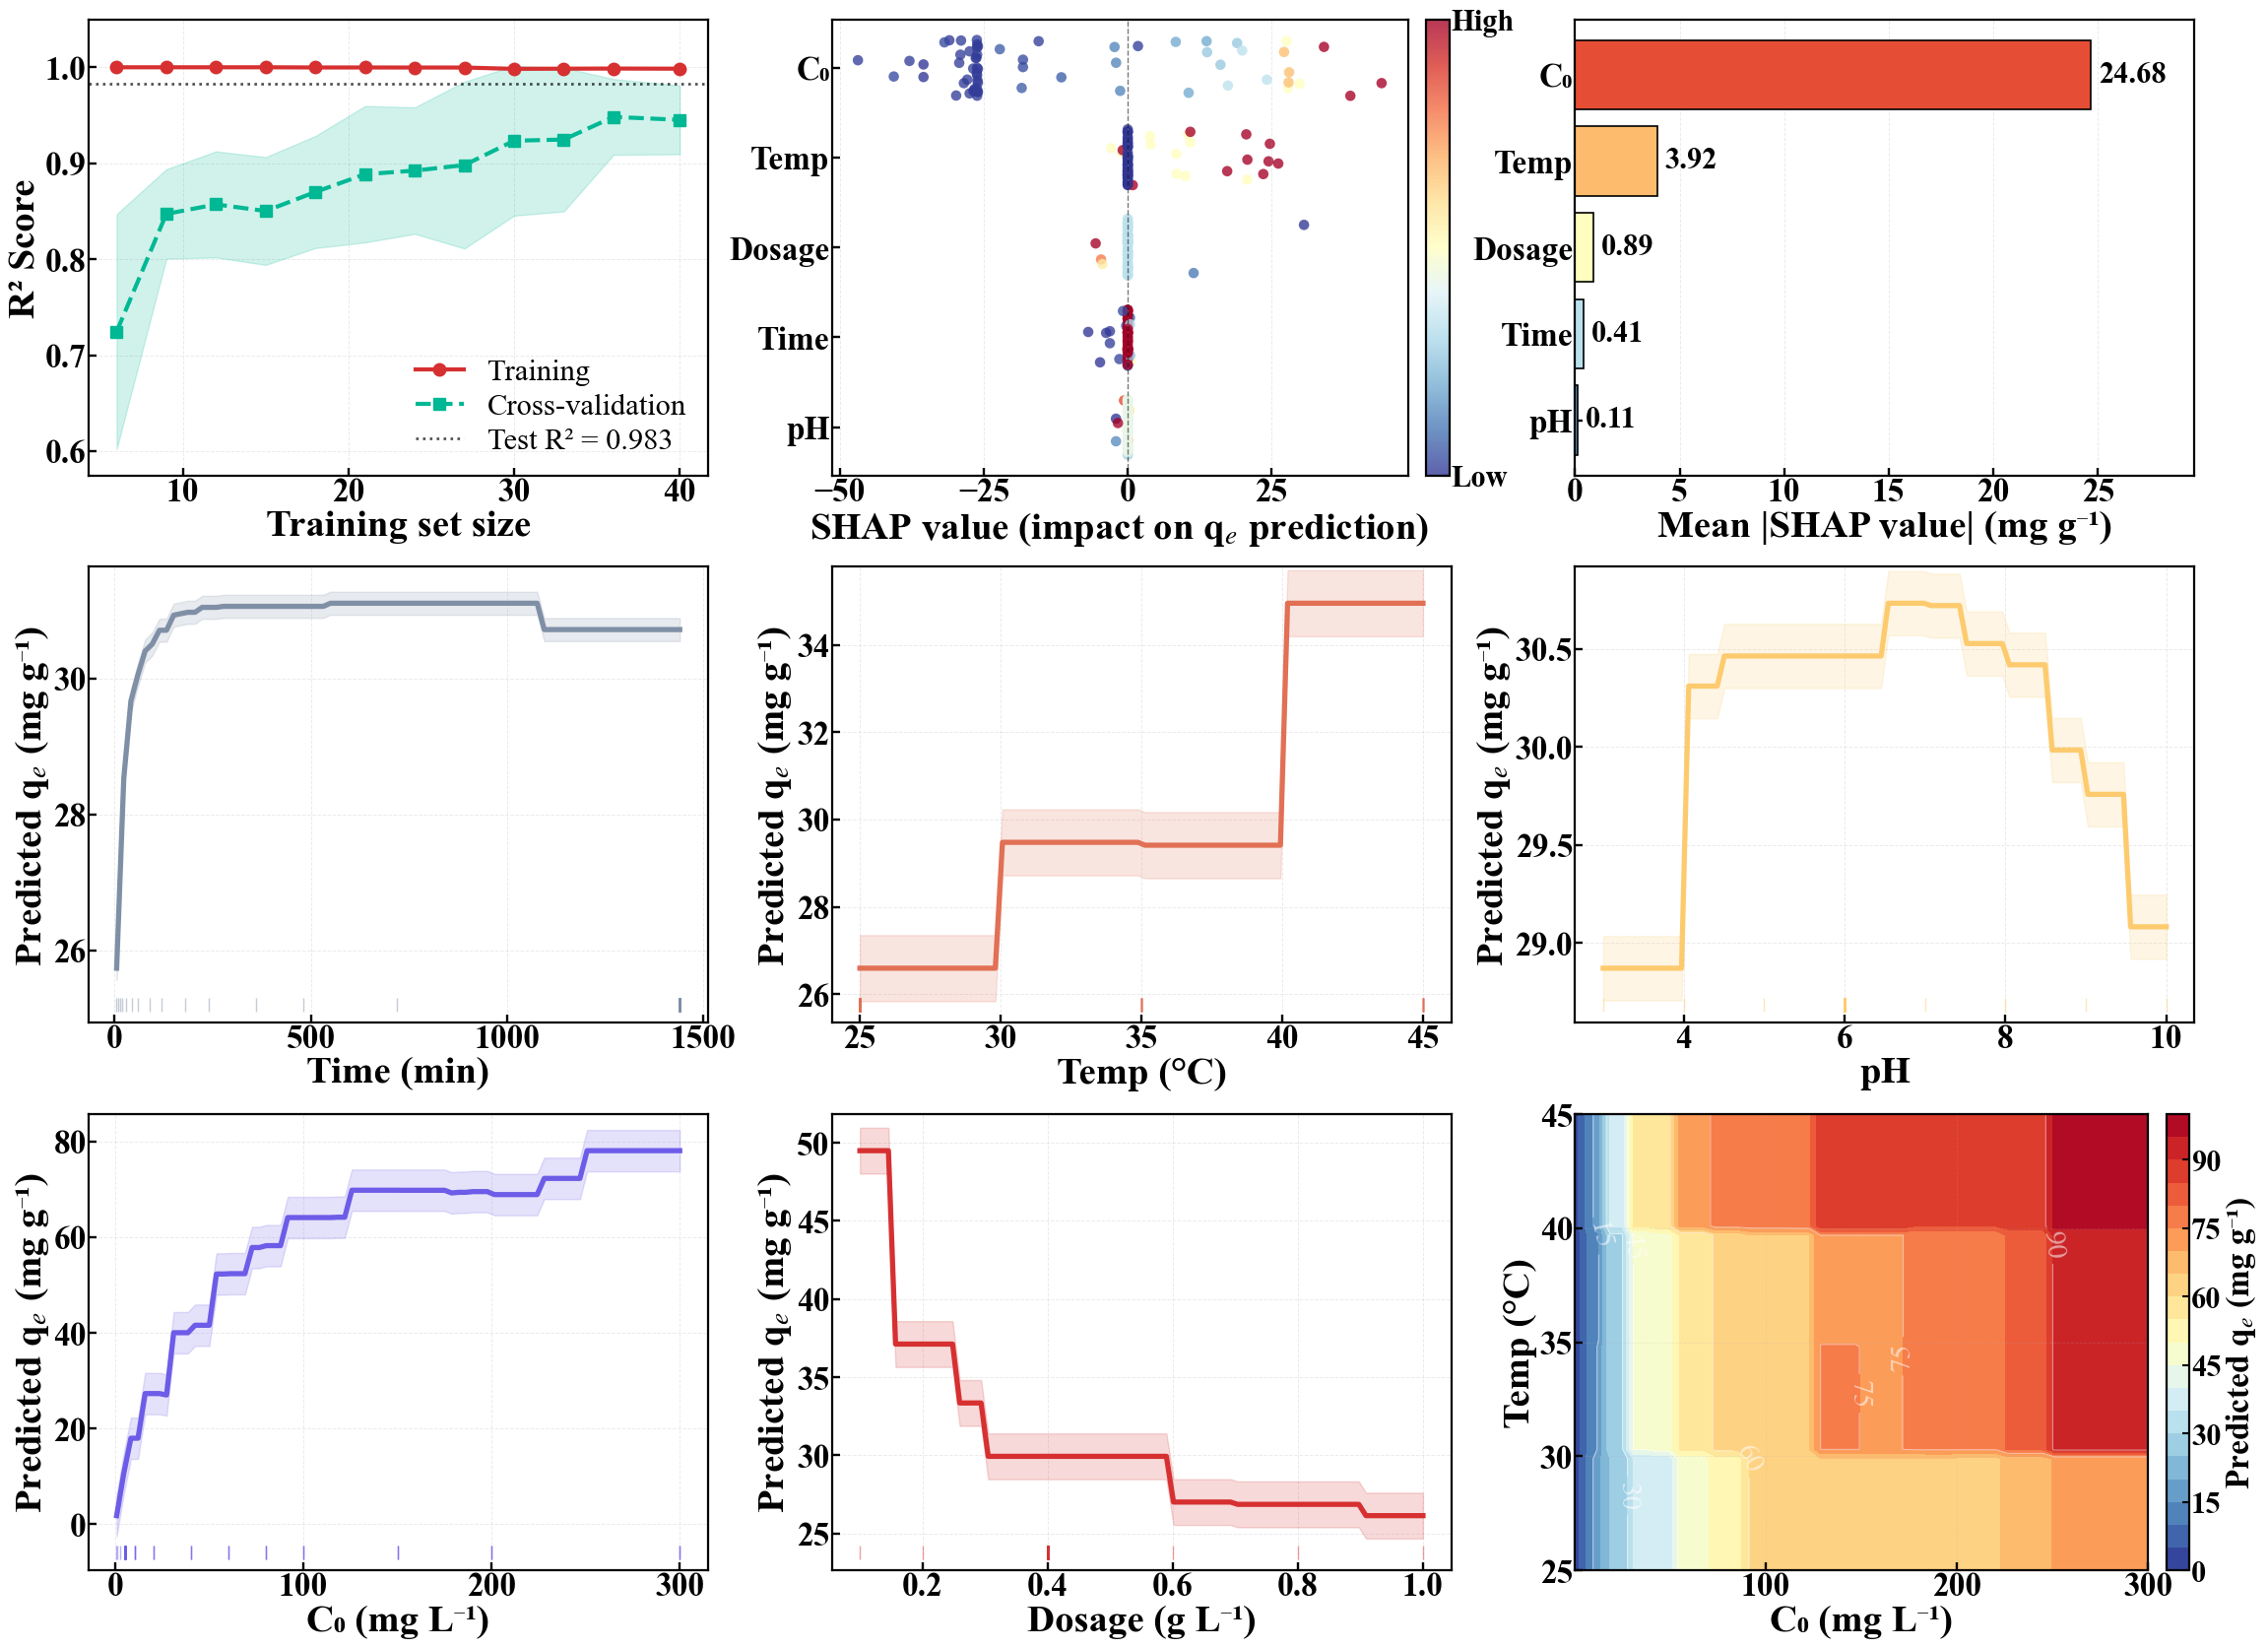


✓ Saved: Fig_GBR_3x3.png and Fig_GBR_3x3.pdf


In [16]:
# 3×3 composite figure — all GBR diagnostics in one panel
fig = plt.figure(figsize=(22, 16.2))
gs = fig.add_gridspec(3, 3,
                      hspace=0.2, wspace=0.2,
                      left=0.026, right=0.998,
                      top=0.998, bottom=0.026)

# ─── (a) Learning curve ───────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
sizes, tr_scores, va_scores = learning_curve(
    gbr, X_tr, y_tr,
    train_sizes=np.linspace(0.15, 1.0, 12),
    cv=5, scoring="r2", n_jobs=1, random_state=RANDOM_SEED
)
tr_m, tr_s = tr_scores.mean(axis=1), tr_scores.std(axis=1)
va_m, va_s = va_scores.mean(axis=1), va_scores.std(axis=1)

ax_a.plot(sizes, tr_m, "o-", color=GBR_COLOR, lw=3.0, ms=9,
          label="Training", zorder=4)
ax_a.fill_between(sizes, tr_m - tr_s, tr_m + tr_s,
                  color=GBR_COLOR, alpha=0.18, zorder=2)
ax_a.plot(sizes, va_m, "s--", color=ACCENT, lw=3.0, ms=9,
          label="Cross-validation", zorder=4)
ax_a.fill_between(sizes, va_m - va_s, va_m + va_s,
                  color=ACCENT, alpha=0.18, zorder=2)
ax_a.axhline(test_r2, color="black", ls=":", lw=1.9, alpha=0.7,
             label=f"Test R² = {test_r2:.3f}")
ax_a.set_xlabel("Training set size")
ax_a.set_ylabel("R² Score")
ax_a.set_ylim(max(va_m.min() - 0.15, 0), 1.05)
ax_a.legend(loc="lower right", fontsize=22, frameon=False, handlelength=1.6, borderpad=0.2, labelspacing=0.25)
ax_a.grid(alpha=0.25, linestyle="--", linewidth=0.7)

# ─── (b) SHAP summary plot (beeswarm) ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
order_b = np.argsort(mean_abs_shap)        # ascending
np.random.seed(0)
for plot_y, fi in enumerate(order_b):
    sv = shap_vals[:, fi]
    fv = X_full[:, fi]
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    jitter = np.random.uniform(-0.32, 0.32, size=n_samp)
    sc = ax_b.scatter(sv, plot_y + jitter, c=fv_norm, cmap="RdYlBu_r",
                      s=58, alpha=0.78, edgecolor="none")

ax_b.axvline(0, color="black", lw=1.0, ls="--", alpha=0.5)
ax_b.set_yticks(range(n_feat))
ax_b.set_yticklabels([feature_names[i] for i in order_b])
ax_b.set_xlabel("SHAP value (impact on q$_e$ prediction)")
ax_b.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.7)
cbar_b = plt.colorbar(sc, ax=ax_b, fraction=0.04, pad=0.03)
# cbar_b.set_label("Feature value", fontsize=18, fontweight="bold")
cbar_b.set_ticks([0, 1]); cbar_b.set_ticklabels(["Low", "High"]); cbar_b.ax.tick_params(labelsize=22, pad=1)

# ─── (c) Feature importance bar ───────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
order_c = np.argsort(mean_abs_shap)
colors_grad = [plt.cm.RdYlBu_r(v) for v in np.linspace(0.15, 0.85, n_feat)]
bars = ax_c.barh(range(n_feat), mean_abs_shap[order_c],
                 color=colors_grad, edgecolor="black", linewidth=1.2)
ax_c.set_yticks(range(n_feat))
ax_c.set_yticklabels([feature_names[i] for i in order_c])
ax_c.set_xlabel("Mean |SHAP value| (mg g⁻¹)")
for bar, v in zip(bars, mean_abs_shap[order_c]):
    ax_c.text(v + mean_abs_shap.max() * 0.015,
              bar.get_y() + bar.get_height()/2,
              f"{v:.2f}", va="center", fontsize=22, fontweight="bold")
ax_c.set_xlim(0, mean_abs_shap.max() * 1.20)
ax_c.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.7)
ax_c.set_axisbelow(True)

# ─── (d)–(h) Partial Dependence Plots for 5 features ──────────────────────
positions = [(1, 0), (1, 1), (1, 2), (2, 0), (2, 1)]
labels    = ["d", "e", "f", "g", "h"]

for fi, pos, lab in zip(range(n_feat), positions, labels):
    ax = fig.add_subplot(gs[pos[0], pos[1]])
    x_vals = np.linspace(X_full[:, fi].min(), X_full[:, fi].max(), 80)
    pd_means = []
    for xv in x_vals:
        X_mod = X_full.copy()
        X_mod[:, fi] = xv
        pd_means.append(gbr.predict(X_mod).mean())
    pd_means = np.array(pd_means)

    c_pdp = palette5[fi]
    ax.plot(x_vals, pd_means, color=c_pdp, lw=3.8, zorder=3)
    ax.fill_between(x_vals,
                    pd_means - pd_means.std() * 0.25,
                    pd_means + pd_means.std() * 0.25,
                    color=c_pdp, alpha=0.18, zorder=2)

    yrange = pd_means.max() - pd_means.min()
    rug_y = pd_means.min() - yrange * 0.10
    ax.plot(X_full[:, fi], np.full(len(X_full), rug_y),
            "|", color=c_pdp, alpha=0.45, markersize=10)
    ax.set_ylim(rug_y - yrange * 0.05, pd_means.max() + yrange * 0.10)

    ax.set_xlabel(feature_full[fi])
    ax.set_ylabel("Predicted q$_e$ (mg g⁻¹)")
    ax.grid(alpha=0.25, linestyle="--", linewidth=0.7)

# ─── (i) 2D Partial Dependence — top-2 features ───────────────────────────
ax_i = fig.add_subplot(gs[2, 2])
top2 = np.argsort(mean_abs_shap)[-2:][::-1]
fi1, fi2 = top2[0], top2[1]
v1_vals = np.linspace(X_full[:, fi1].min(), X_full[:, fi1].max(), 50)
v2_vals = np.linspace(X_full[:, fi2].min(), X_full[:, fi2].max(), 50)
pd_grid = np.zeros((50, 50))
for i, v1 in enumerate(v1_vals):
    for j, v2 in enumerate(v2_vals):
        X_mod = X_full.copy()
        X_mod[:, fi1] = v1
        X_mod[:, fi2] = v2
        pd_grid[j, i] = gbr.predict(X_mod).mean()

im = ax_i.contourf(v1_vals, v2_vals, pd_grid, levels=20, cmap="RdYlBu_r")
cs = ax_i.contour(v1_vals, v2_vals, pd_grid, levels=8, colors="white",
                  linewidths=0.7, alpha=0.55)
ax_i.clabel(cs, inline=True, fontsize=21, fmt="%.0f")
cbar_i = plt.colorbar(im, ax=ax_i, fraction=0.045, pad=0.03)
cbar_i.set_label("Predicted q$_e$ (mg g⁻¹)", fontsize=24, fontweight="bold", labelpad=2)
ax_i.set_xlabel(feature_full[fi1])
ax_i.set_ylabel(feature_full[fi2])
ax_i.grid(alpha=0.20, linestyle="--", linewidth=0.6)


# Bigger fonts and tighter label padding for every 3×3 panel
# These settings are intentionally explicit so the final 3×3 figure is visibly larger.
for ax in fig.axes:
    ax.set_title("")  # remove subplot titles
    ax.xaxis.label.set_size(28)
    ax.yaxis.label.set_size(28)
    ax.xaxis.label.set_weight("bold")
    ax.yaxis.label.set_weight("bold")
    ax.xaxis.labelpad = 2
    ax.yaxis.labelpad = 2
    ax.tick_params(axis="both", which="major", labelsize=24, pad=1.5, width=1.7, length=6)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontsize(24)
        tick.set_fontweight("bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)

# Colorbar fonts
for cax in [cbar_b.ax, cbar_i.ax]:
    cax.tick_params(labelsize=22, pad=1.5, width=1.5, length=5)
    cax.yaxis.label.set_size(24)
    cax.yaxis.label.set_weight("bold")

# Make selected annotation fonts larger
for txt in ax_c.texts:
    txt.set_fontsize(22)
    txt.set_fontweight("bold")

plt.savefig("Fig_GBR_3x3.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("Fig_GBR_3x3.pdf", bbox_inches="tight")
plt.show()
print("\n✓ Saved: Fig_GBR_3x3.png and Fig_GBR_3x3.pdf")